In [ ]:
#16.Load monthly sales data
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from statsmodels.tsa.holtwinters import ExponentialSmoothing
from statsmodels.tsa.arima.model import ARIMA
from sklearn.metrics import mean_absolute_error

data = pd.read_csv("monthly_sales.csv")

print("Top 5 rows:")
print(data.head())

print("\nColumn names:")
print(data.columns)

Top 5 rows:
    month  sales
0  Jan-22    120
1  Feb-22    135
2  Mar-22    128
3  Apr-22    145
4  May-22    150

Column names:
Index(['month', 'sales'], dtype='str')


In [18]:
#17.Convert Month column into date format
data['month'] = pd.to_datetime(data['month'], format='%b-%Y')

data = data.set_index('month')

print(data.head())
print(data.index)

         sales
month         
1-01-22    120
1-02-22    135
1-03-22    128
1-04-22    145
1-05-22    150
DatetimeIndex(['1-01-22', '1-02-22', '1-03-22', '1-04-22', '1-05-22',
               '1-06-22', '1-07-22', '1-08-22', '1-09-22', '1-10-22',
               '1-11-22', '1-12-22', '1-01-23', '1-02-23', '1-03-23',
               '1-04-23', '1-05-23', '1-06-23', '1-07-23', '1-08-23',
               '1-09-23', '1-10-23', '1-11-23', '1-12-23', '1-01-24',
               '1-02-24', '1-03-24', '1-04-24', '1-05-24', '1-06-24',
               '1-07-24', '1-08-24', '1-09-24', '1-10-24', '1-11-24',
               '1-12-24', '1-01-25', '1-02-25', '1-03-25', '1-04-25',
               '1-05-25', '1-06-25', '1-07-25', '1-08-25', '1-09-25',
               '1-10-25', '1-11-25', '1-12-25', '1-01-26', '1-02-26'],
              dtype='datetime64[us]', name='month', freq=None)


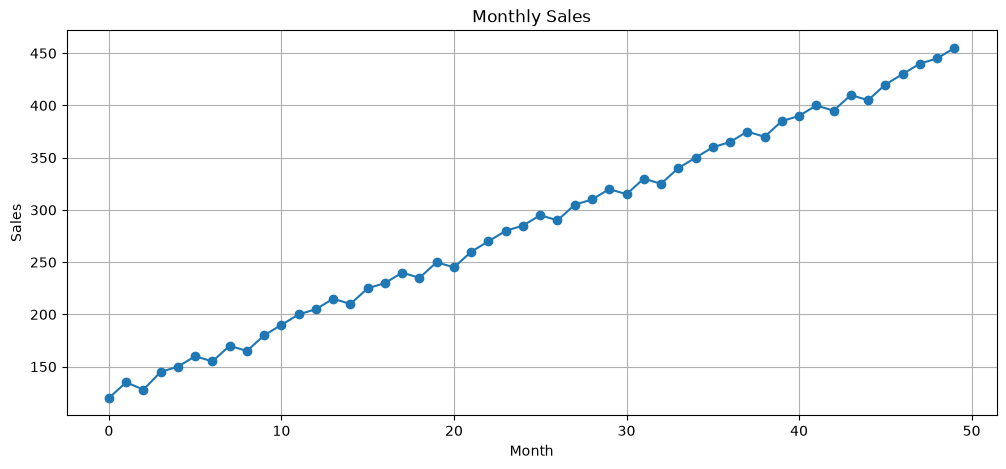

In [11]:
#18: Plot monthly sales using a line chart
plt.figure(figsize=(12, 5))

plt.plot(data.index, data['sales'], marker='o')

plt.title("Monthly Sales")
plt.xlabel("Month")
plt.ylabel("Sales")

plt.grid(True)
plt.show()

In [12]:
#19: Observe the trend
print("The sales show an overall increasing trend over time.")

The sales show an overall increasing trend over time.


In [15]:
#20: Apply Exponential Smoothing
es_model = ExponentialSmoothing(
    data['sales'],
    trend='add',
    seasonal=None
)

es_fit = es_model.fit()

print("Exponential Smoothing applied successfully.")

Exponential Smoothing applied successfully.


In [16]:
#21: Forecast the next 3 months
es_forecast = es_fit.forecast(3)

print("Exponential Smoothing Forecast:")
print(es_forecast)

Exponential Smoothing Forecast:
50    456.013060
51    462.701416
52    469.389771
dtype: float64


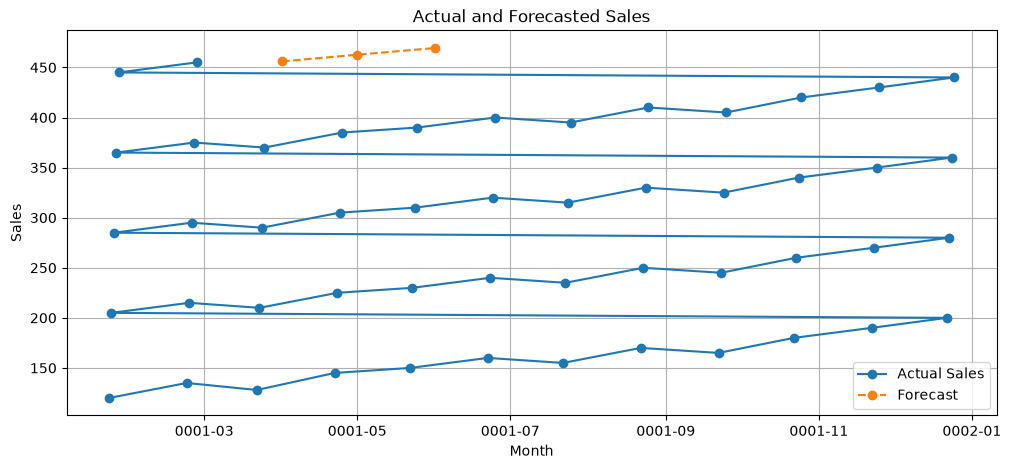

In [19]:
#22: Plot actual and forecasted sales
future_dates = pd.date_range(
    start=data.index[-1] + pd.DateOffset(months=1),
    periods=3,
    freq='MS'
)

plt.figure(figsize=(12, 5))

plt.plot(
    data.index,
    data['sales'],
    marker='o',
    label='Actual Sales'
)

plt.plot(
    future_dates,
    es_forecast,
    marker='o',
    linestyle='--',
    label='Forecast'
)

plt.title("Actual and Forecasted Sales")
plt.xlabel("Month")
plt.ylabel("Sales")

plt.legend()
plt.grid(True)
plt.show()

In [21]:
#23: Calculate forecasting error
train = data['sales'][:-3]
test = data['sales'][-3:]
es_test_model = ExponentialSmoothing(
    train,
    trend='add',
    seasonal=None
)
es_test_fit = es_test_model.fit()
es_prediction = es_test_fit.forecast(3)
es_mae = mean_absolute_error(
    test,
    es_prediction
)
print("Exponential Smoothing MAE:", es_mae)

Exponential Smoothing MAE: 5.166086138528537


c:\Users\itlab\AppData\Local\Programs\Python\Python314\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
c:\Users\itlab\AppData\Local\Programs\Python\Python314\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: A date index has been provided, but it is not monotonic and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
c:\Users\itlab\AppData\Local\Programs\Python\Python314\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:837: ValueWarning: No supported index is available. Prediction results will be given with an integer index beginning at `start`.
  return get_prediction_index(
c:\Users\itlab\AppData\Local\Programs\Python\Python314\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:837: FutureWarning: No supported index is available. In the next version, calling t

In [23]:
#24: Apply ARIMA to the same data
arima_model = ARIMA(
    data['sales'],
    order=(1, 1, 0)
)
arima_fit = arima_model.fit()
print("ARIMA applied successfully.")

ARIMA applied successfully.


c:\Users\itlab\AppData\Local\Programs\Python\Python314\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
c:\Users\itlab\AppData\Local\Programs\Python\Python314\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: A date index has been provided, but it is not monotonic and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
c:\Users\itlab\AppData\Local\Programs\Python\Python314\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
c:\Users\itlab\AppData\Local\Programs\Python\Python314\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: A date index has been provided, but it is not mo

In [24]:
#25: Forecast the next 3 months using ARIMA
arima_forecast = arima_fit.forecast(steps=3)
print("ARIMA Forecast:")
print(arima_forecast)

ARIMA Forecast:
50    455.431732
51    455.450371
52    455.451176
Name: predicted_mean, dtype: float64


c:\Users\itlab\AppData\Local\Programs\Python\Python314\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:837: ValueWarning: No supported index is available. Prediction results will be given with an integer index beginning at `start`.
  return get_prediction_index(
c:\Users\itlab\AppData\Local\Programs\Python\Python314\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:837: FutureWarning: No supported index is available. In the next version, calling this method in a model without a supported index will result in an exception.
  return get_prediction_index(


In [26]:
#26: Compare ARIMA and Exponential Smoothing forecasts
comparison = pd.DataFrame({
    'month': future_dates,
    'Exponential_Smoothing': es_forecast.values,
    'ARIMA': arima_forecast.values
})
print("Forecast Comparison:")
print(comparison)

Forecast Comparison:
    month  Exponential_Smoothing       ARIMA
0 1-04-01             456.013060  455.431732
1 1-05-01             462.701416  455.450371
2 1-06-01             469.389771  455.451176


In [27]:
#27: Calculate and compare forecasting errors
arima_test_model = ARIMA(
    train,
    order=(1, 1, 0)
)
arima_test_fit = arima_test_model.fit()
arima_prediction = arima_test_fit.forecast(steps=3)
arima_mae = mean_absolute_error(
    test,
    arima_prediction
)
print("Exponential Smoothing MAE:", es_mae)
print("ARIMA MAE:", arima_mae)

Exponential Smoothing MAE: 5.166086138528537
ARIMA MAE: 16.642601736440458


c:\Users\itlab\AppData\Local\Programs\Python\Python314\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
c:\Users\itlab\AppData\Local\Programs\Python\Python314\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: A date index has been provided, but it is not monotonic and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
c:\Users\itlab\AppData\Local\Programs\Python\Python314\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
c:\Users\itlab\AppData\Local\Programs\Python\Python314\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: A date index has been provided, but it is not mo

In [28]:
#28: Identify which model gives lower forecasting error
if es_mae < arima_mae:
    print("Exponential Smoothing gives the lower forecasting error.")
elif arima_mae < es_mae:
    print("ARIMA gives the lower forecasting error.")
else:
    print("Both models have the same forecasting error.")

Exponential Smoothing gives the lower forecasting error.
